The models that were trained are: LinearRegression, RandomForestRegressor, XGBRegressor and a Deep Learning Model. 
Grid searches to find the best hyperparameters were performed. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
data_dir = "data/"

In [4]:
train_features = pd.read_csv(f'{data_dir}train_processed.csv')
train_features

,hsize,num_children5,num_children10,num_children18,age,num_adult_female,num_adult_male,num_elderly,sworkershh,share_secondary,...,sector1d_Manufacturing,sector1d_Mining and quarrying,"sector1d_Other community, social and personal service activities",sector1d_Public administration and defence,"sector1d_Real estate, renting and business activities","sector1d_Transport, storage and communications",sector1d_Wholesale and retail trade,sector1d_nan,utl_exp_ppp17,weight
0,1,0,0,0,75,0,0,1,0.000000,0.000000,...,0,0,0,0,0,0,0,1,594.80627,75
1,2,0,0,0,61,1,0,1,0.000000,0.000000,...,0,0,0,0,0,0,0,1,1676.27230,150
2,5,0,0,2,49,1,2,0,0.666667,0.333333,...,0,0,0,0,0,1,0,0,506.93719,375
3,5,0,0,1,58,1,3,0,1.250000,0.250000,...,0,0,0,1,0,0,0,0,824.61786,375
4,7,1,0,0,57,2,3,1,0.666667,0.333333,...,0,0,0,0,0,0,0,0,351.47644,525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104229,4,2,1,0,33,1,0,0,1.000000,0.000000,...,0,0,0,0,0,0,0,0,143.58849,616
104230,4,0,0,1,48,3,0,0,0.000000,0.333333,...,0,0,0,0,0,0,0,1,268.44803,616
104231,10,2,3,2,54,2,1,0,1.000000,0.333333,...,0,0,0,0,0,0,0,1,243.47612,1540
104232,8,0,0,3,49,1,4,0,1.000000,0.200000,...,0,0,0,0,0,0,1,0,337.12079,1232


In [5]:
train_consumption = pd.read_csv(f'{data_dir}train_hh_gt.csv')
train_consumption

,survey_id,hhid,cons_ppp17
0,100000,100001,25.258402
1,100000,100002,16.996706
2,100000,100003,13.671848
3,100000,100004,7.189475
4,100000,100005,12.308855
...,...,...,...
104229,300000,337458,2.830888
104230,300000,337459,3.144309
104231,300000,337460,3.319158
104232,300000,337461,6.088739


In [6]:
train_features['cons_ppp17'] = train_consumption['cons_ppp17']#target variable

In [7]:
df_clean = train_features.dropna()
df_clean.shape

(104126, 73)

In [8]:
x=df_clean.drop(columns=['cons_ppp17','weight'])
y=df_clean[['cons_ppp17']]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

x_train.shape , x_test.shape

((72888, 71), (31238, 71))

In [10]:
#test_weights = df_clean.loc[x_test.index, 'weight']
#np.save('test_weights.npy', test_weights.values)
#test_weights

In [11]:
scaler = StandardScaler()
target_scaler = StandardScaler()

In [31]:
joblib.dump(target_scaler,'target_scaler.pkl')
print("Scaler saved successfully!")

Scaler saved successfully!


In [12]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train_scaled = target_scaler.fit_transform(y_train)
y_test_scaled = target_scaler.transform(y_test)

In [12]:
lin_reg = LinearRegression()

In [13]:
lin_reg.fit(x_train_scaled, y_train_scaled)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred_lin = lin_reg.predict(x_test_scaled)

In [15]:
y_pred_original = target_scaler.inverse_transform(y_pred_lin)
y_test_original = target_scaler.inverse_transform(y_test_scaled)

In [20]:
mse_list = []
mae_list = []
r2_list = []
models = []

In [17]:
y_test_val = y_test.values

In [22]:
#np.save('my_predictions.npy', y_pred_fixed)

In [18]:
y_pred_fixed = np.maximum(y_pred_original, 0)
mse = mean_squared_error(y_test_val, y_pred_fixed)
mae =mean_absolute_error(y_test_val, y_pred_fixed)
r2=r2_score(y_test_val, y_pred_fixed)

mse_list.append(mse)
mae_list.append(mae)
r2_list.append(r2)
models.append('LinearRegression')

print(f'MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')


MSE: 49.54, MAE: 4.20, R2: 0.52


In [19]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
params_rf= {'n_estimators': [100, 200], 'max_depth': [10, 20, None],'min_samples_leaf': [1, 4]}

search_rf =RandomizedSearchCV(rf, params_rf, n_iter=5, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
search_rf.fit(x_train_scaled, y_train_scaled)

C:\Users\giorg\anaconda3\envs\rapids\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 4], 'n_estimators': [100, 200]}"
,n_iter,5
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [20]:
search_rf.best_params_

{'n_estimators': 100, 'min_samples_leaf': 4, 'max_depth': None}

In [21]:
best_rf = search_rf.best_estimator_
y_pred_rf = best_rf.predict(x_test_scaled)
y_pred_rf_original = target_scaler.inverse_transform(y_pred_rf.reshape(-1, 1))

y_pred_fixed = np.maximum(y_pred_rf_original, 0)
mse = mean_squared_error(y_test_val, y_pred_fixed)
mae =mean_absolute_error(y_test_val, y_pred_fixed)
r2=r2_score(y_test_val, y_pred_fixed)

mse_list.append(mse)
mae_list.append(mae)
r2_list.append(r2)
models.append('RandomForestRegressor')

print(f'RandomForestRegressor MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')

RandomForestRegressor MSE: 42.91, MAE: 3.69, R2: 0.58


In [22]:
xgb =XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)

In [23]:
params_xgb ={'n_estimators': [100, 300],'learning_rate': [0.01, 0.1],'max_depth': [3, 6, 10],'subsample': [0.7, 1.0]}

In [24]:
search_xgb =RandomizedSearchCV(xgb, params_xgb, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
search_xgb.fit(x_train_scaled,y_train_scaled)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 6, ...], 'n_estimators': [100, 300], 'subsample': [0.7, 1.0]}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
search_xgb.best_params_

{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}

In [26]:
best_xgb = search_xgb.best_estimator_
y_pred_xgb =best_xgb.predict(x_test_scaled)
y_pred_xgb_original= target_scaler.inverse_transform(y_pred_xgb.reshape(-1, 1))

In [27]:
y_pred_fixed= np.maximum(y_pred_xgb_original, 0)
mse = mean_squared_error(y_test_val, y_pred_fixed)
mae =mean_absolute_error(y_test_val, y_pred_fixed)
r2=r2_score(y_test_val, y_pred_fixed)

mse_list.append(mse)
mae_list.append(mae)
r2_list.append(r2)
models.append('XGBRegressor')

print(f'XGBRegressor MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')

XGBRegressor MSE: 40.77, MAE: 3.58, R2: 0.61


In [13]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\giorg\anaconda3\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
early_stop= EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [15]:
history = model.fit(x_train_scaled, y_train_scaled,validation_split=0.2,epochs=100,batch_size=32, callbacks=[early_stop],verbose=0)

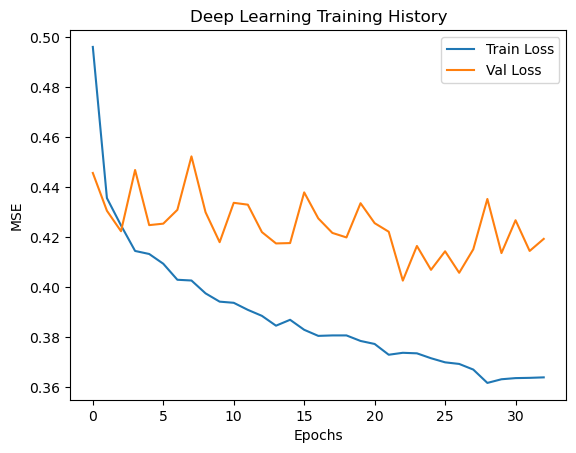

In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.title('Deep Learning Training History')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [17]:
y_pred_dl= model.predict(x_test_scaled).flatten()
y_pred_dl_original = target_scaler.inverse_transform(y_pred_dl.reshape(-1, 1))

977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [18]:
y_test_val=y_test.values

In [21]:
y_pred_fixed = np.maximum(y_pred_dl_original, 0)
mse = mean_squared_error(y_test_val, y_pred_fixed)
mae =mean_absolute_error(y_test_val, y_pred_fixed)
r2=r2_score(y_test_val, y_pred_fixed)

mse_list.append(mse)
mae_list.append(mae)
r2_list.append(r2)
models.append('DL')

print(f'Deep Learning MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')

Deep Learning MSE: 42.70, MAE: 3.78, R2: 0.59


In [ ]:
model.save('my_model.h5')
print("Model saved!")